<a href="https://colab.research.google.com/github/sanjaypras/crispr_pred/blob/main/genome_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

In [5]:
df = pd.read_csv('V1_suppl_data.txt', sep='\t')

In [6]:
df.head(20)

,Spacer Sequence,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Transcript,Gene Symbol,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Annotation,Activity,Percent Rank
0,CTGATCTCCAGATATGACCA,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,sense,ENSMUST00000182755,CD45,242,2.0,0.18,CDS,2.308903,0.346278
1,TGATCTCCAGATATGACCAT,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,sense,ENSMUST00000182755,CD45,243,2.0,0.18,CDS,2.530273,0.365696
2,AAGTTTGAGCCACAAACCCA,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,antisense,ENSMUST00000182755,CD45,248,4.0,0.35,CDS,4.098996,0.857605
3,CAGATATGACCATGGGTTTG,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,sense,ENSMUST00000182755,CD45,250,5.0,0.44,CDS,3.807251,0.705502
4,GGGTTTGTGGCTCAAACTTC,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,sense,ENSMUST00000182755,CD45,263,9.0,0.80,CDS,1.585304,0.258900
5,TGGCTCAAACTTCTGGCCTT,TTTGTGGCTCAAACTTCTGGCCTTTGGATTTGCC,sense,ENSMUST00000182755,CD45,270,11.0,0.97,CDS,-3.768976,0.006472
6,GTCCAGAAGGGCAAATCCAA,CTGTGTCCAGAAGGGCAAATCCAAAGGCCAGAAG,antisense,ENSMUST00000182755,CD45,275,13.0,1.15,CDS,3.816749,0.711974
7,GGCCTTTGGATTTGCCCTTC,TTCTGGCCTTTGGATTTGCCCTTCTGGACACAGA,sense,ENSMUST00000182755,CD45,284,16.0,1.42,CDS,1.247028,0.207120
8,AAAGACTTCTGTGTCCAGAA,TGACAAAGACTTCTGTGTCCAGAAGGGCAAATCC,antisense,ENSMUST00000182755,CD45,287,17.0,1.50,CDS,4.559195,0.996764
9,CAAAGACTTCTGTGTCCAGA,GTGACAAAGACTTCTGTGTCCAGAAGGGCAAATC,antisense,ENSMUST00000182755,CD45,288,17.0,1.50,CDS,3.497215,0.569579


In [7]:
df.describe()

,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Activity,Percent Rank
count,2144.000000,2135.000000,2135.000000,2144.000000,2144.000000
mean,18711.790578,303.029508,47.334014,1.901516,0.502099
std,30899.375678,250.681202,27.950229,1.903784,0.288742
min,56.000000,2.000000,0.180000,-6.603273,0.002198
25%,1052.750000,114.000000,23.510000,0.572749,0.252667
50%,8555.500000,246.000000,47.610000,1.730833,0.502252
75%,15748.750000,402.000000,69.920000,3.635408,0.751337
max,110815.000000,1130.000000,100.000000,6.305269,1.000000


In [8]:
df = df.drop(columns=['Spacer Sequence', 'Transcript', 'Nucleotide cut position', 'Amino Acid Cut position', 'Annotation'])

In [9]:
df.head()

,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Gene Symbol,Percent Peptide,Activity,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,sense,CD45,0.18,2.308903,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,sense,CD45,0.18,2.530273,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,antisense,CD45,0.35,4.098996,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,sense,CD45,0.44,3.807251,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,sense,CD45,0.80,1.585304,0.258900


In [10]:
df['Strand'] = df['Strand'].astype(str).str.strip().str.lower()
df['Strand'] = df['Strand'].map({'sense': 1, 'antisense': 0})
df.head()

,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Gene Symbol,Percent Peptide,Activity,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,1,CD45,0.18,2.308903,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,1,CD45,0.18,2.530273,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,0,CD45,0.35,4.098996,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,1,CD45,0.44,3.807251,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,1,CD45,0.80,1.585304,0.258900


In [11]:
df.rename(columns={'Extended Spacer(NNNN[20nt]NGGNNNNNNN)': 'Spacer'}, inplace=True)


In [12]:
df.head()

,Spacer,Strand,Gene Symbol,Percent Peptide,Activity,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,1,CD45,0.18,2.308903,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,1,CD45,0.18,2.530273,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,0,CD45,0.35,4.098996,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,1,CD45,0.44,3.807251,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,1,CD45,0.80,1.585304,0.258900


In [15]:
import numpy as np

def prepare_final_dataset(df):
    # 1. Define One-Hot Mapping
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}

    # 2. Encode DNA (Extended Spacer)
    # This turns the column of strings into a (Rows x 120) matrix
    dna_list = []
    for seq in df['Spacer']:
        bits = []
        for base in seq.upper():
            bits.extend(mapping.get(base, [0,0,0,0]))
        dna_list.append(bits)
    X_dna = np.array(dna_list)

    # 3. Pull Numerical Features (Extras)
    # We use .values to get a NumPy array of (Rows x 3)
    X_extras = df[['Percent Peptide', 'Strand']].values

    # 4. Concatenate DNA + Extras = 123 Features
    X = np.hstack([X_dna, X_extras])

    # 5. Set Target (y)
    y = df['Percent Rank'].values

    return X, y

# Execute
X, y = prepare_final_dataset(df)

print(f"Features (X) shape: {X.shape}") # Should be (N, 123)
print(f"Target (y) shape: {y.shape}")     # Should be (N,)

Features (X) shape: (2144, 138)
Target (y) shape: (2144,)


In [16]:
import numpy as np

# 1. Check the whole matrix
has_nan = np.isnan(X).any()
print(f"Does X have NaNs? {has_nan}")

# 2. Find exactly where they are (if any)
if has_nan:
    nan_cols = np.where(np.isnan(X).any(axis=0))[0]
    print(f"NaNs found in column indices: {nan_cols}")

    # Quick fix: Replace NaNs with 0 (or the mean of the column)
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

Does X have NaNs? True
NaNs found in column indices: [136]


In [17]:
from scipy import stats

# We only check the numerical columns (the last 18 features in your case)
# Assuming 120-137 are your numerical/extra features
numerical_X = X[:, 120:]

z_scores = np.abs(stats.zscore(numerical_X))
outliers = np.where(z_scores > 3)

print(f"Number of outlier data points detected: {len(outliers[0])}")

Number of outlier data points detected: 0


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data is now clean, outlier-checked, and scaled!")

Data is now clean, outlier-checked, and scaled!


In [23]:
X_scaled

array([[ 1.90281099, -0.6168904 , -0.58884095, ..., -0.53780695,
        -1.69101899,  1.06060177],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
        -1.69101899,  1.06060177],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
        -1.68492252, -0.94286096],
       ...,
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
         1.00792599, -0.94286096],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
         0.17270902, -0.94286096],
       [ 1.90281099, -0.6168904 , -0.58884095, ..., -0.53780695,
        -1.29797572, -0.94286096]])

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Basic Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = model.predict(X_test)

# Since Percent Rank must be between 0 and 1, we clip any "overflow" predictions
y_pred = np.clip(y_pred, 0, 1)

In [25]:
# Calculate Spearman Correlation
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"--- Model Results ---")
print(f"Spearman Correlation: {spearman_corr:.4f}")
print(f"Mean Absolute Error:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R-squared Score:      {r2_score(y_test, y_pred):.4f}")

--- Model Results ---
Spearman Correlation: 0.4262
Mean Absolute Error:  0.2188
R-squared Score:      0.1701


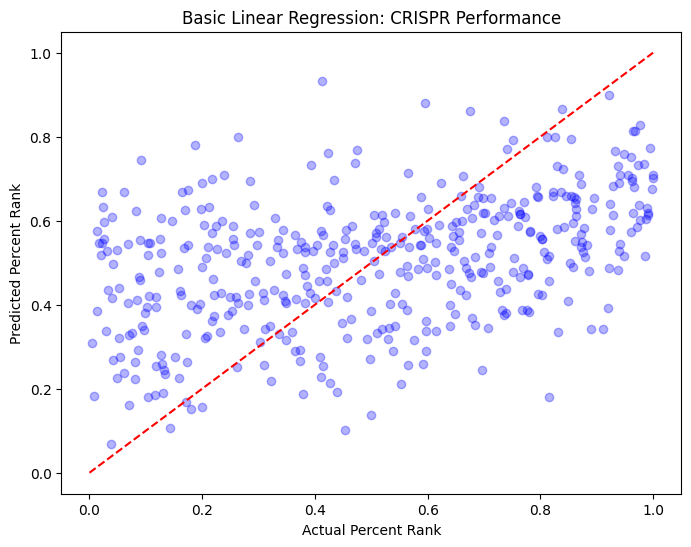

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # The "Perfect Prediction" line
plt.xlabel('Actual Percent Rank')
plt.ylabel('Predicted Percent Rank')
plt.title('Basic Linear Regression: CRISPR Performance')
plt.show()

--- LR Model Results ---  
Spearman Correlation: 0.4262  
Mean Absolute Error:  0.2188  
R-squared Score:      0.1701  

thoughts:  
coud be better, but not a bad start;
definielty room to improve  


###lets try xgb

In [29]:
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error

# 1. Initialize the XGBoost Regressor
# These are standard "starting" parameters for biological data
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,    # Number of trees
    learning_rate=0.05,  # How fast it learns (smaller is usually better)
    max_depth=6,         # How deep/complex each tree can be
    subsample=0.8,       # Uses 80% of data for each tree to prevent overfitting
    random_state=42
)

# 2. Train
xgb_model.fit(X_train, y_train)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, 1) # Keep results in 0-1 range

# 4. Evaluate
spearman_xgb, _ = spearmanr(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"--- XGBoost Model Results ---")
print(f"Spearman Correlation: {spearman_xgb:.4f}")
print(f"Mean Absolute Error:  {mae_xgb:.4f}")

--- XGBoost Model Results ---
Spearman Correlation: 0.5750
Mean Absolute Error:  0.1934


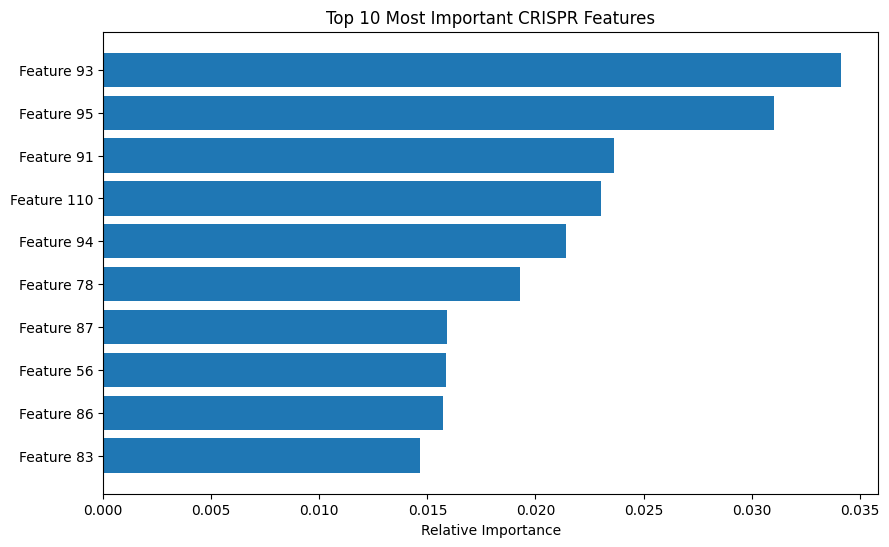

In [30]:
import matplotlib.pyplot as plt

# Get the top 10 most important features
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.title("Top 10 Most Important CRISPR Features")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"Feature {i}" for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [31]:
# If you used the hstack method:
# 0-119 are DNA bits.
# 120+ are your numerical columns.

def get_feature_name(index):
    if index < 120:
        pos = index // 4
        base = ['A', 'C', 'G', 'T'][index % 4]
        return f"DNA Pos {pos} (Base {base})"
    else:
        # Check the order of your extra_features list
        extras = ['Percent Peptide', 'Strand', 'Cut Position', ...]
        return extras[index - 120]

print(f"Feature 93 is: {get_feature_name(93)}")

Feature 93 is: DNA Pos 23 (Base C)


--- XGBoost Model Results ---  
Spearman Correlation: 0.5750  
Mean Absolute Error:  0.1934

thoughts:  
better thean lr(expected)  
still room to improve  

##lets try nn now

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers # Added regularizers here
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import spearmanr

# 1. Define the Architecture
model = models.Sequential([
    # Layer 1: Input + L2 + BatchNorm
    layers.Dense(64, kernel_regularizer=regularizers.l2(0.01), input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    # Layer 2: Shrinking + L2 + BatchNorm
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Layer 3: Final refinement
    layers.Dense(16),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # Output: Sigmoid for 0-1 range
    layers.Dense(1, activation='sigmoid')
])

# 2. Compile with a slightly slower learning rate for stability
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

# 3. Early Stopping (The "Anti-Overfit" Guard)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 4. Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate
y_pred_nn = model.predict(X_test).flatten()
spearman_nn, _ = spearmanr(y_test, y_pred_nn)

print(f"\n--- Improved Neural Network Results ---")
print(f"Spearman Correlation: {spearman_nn:.4f}")

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1.2196 - mae: 0.2612 - val_loss: 1.0538 - val_mae: 0.2588
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9173 - mae: 0.2555 - val_loss: 0.7880 - val_mae: 0.2459
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6914 - mae: 0.2499 - val_loss: 0.5943 - val_mae: 0.2380
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5293 - mae: 0.2502 - val_loss: 0.4538 - val_mae: 0.2353
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4110 - mae: 0.2486 - val_loss: 0.3548 - val_mae: 0.2369
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3225 - mae: 0.2431 - val_loss: 0.2837 - val_mae: 0.2394
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2592 - mae: 0.2413 - val_loss: 0.2330 - val_mae: 0.2423
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2157 - mae: 0.2437 - val_loss: 0.1959 - val_mae: 0.2437
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.18

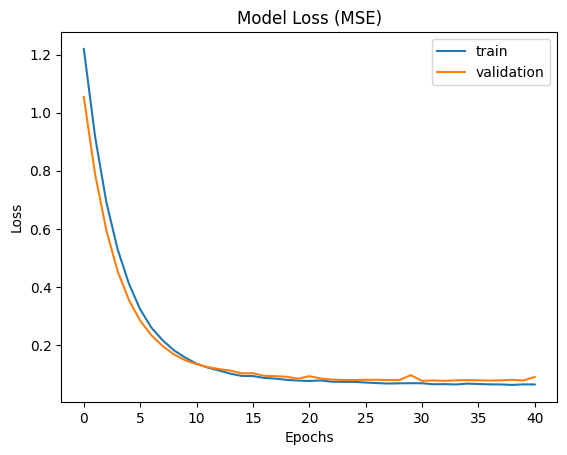

In [38]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

--- Improved Neural Network Results ---  
Spearman Correlation: 0.5124

thoughts:  
nn didnt have enough data to run well  
xgboost was the best, so lets try and run shap on the xgb model

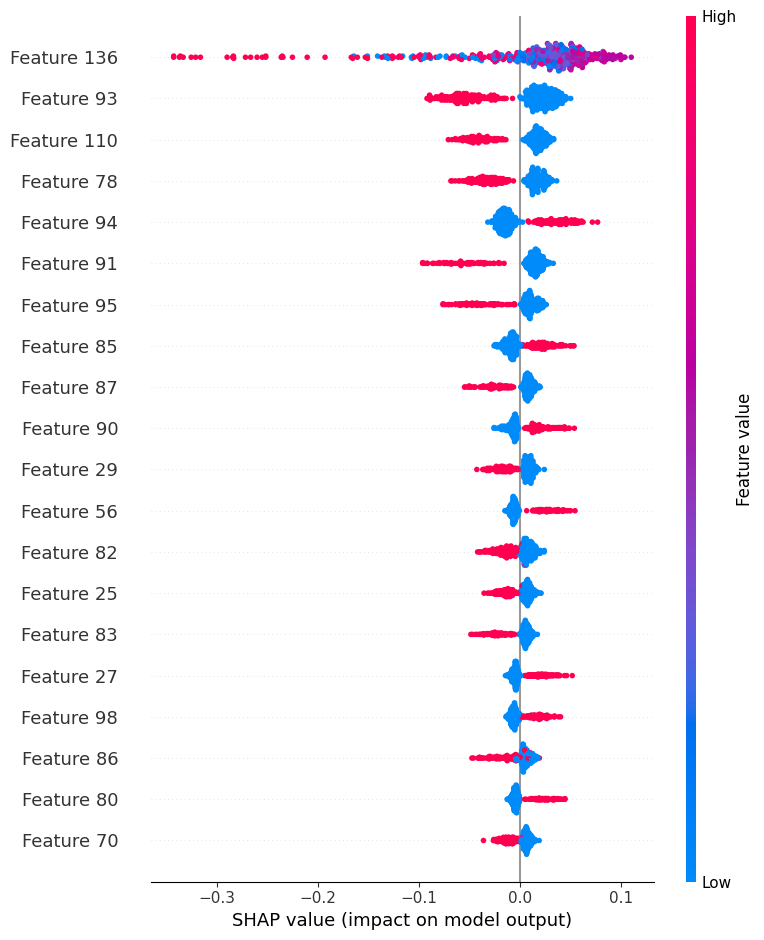

In [39]:
import shap
import matplotlib.pyplot as plt

# 1. Create the SHAP Explainer for XGBoost
# TreeExplainer is lightning-fast and specifically built for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# 2. Visualize: The Summary Plot
# This is the "Everything" plot: Importance + Direction
shap.summary_plot(shap_values, X_test, plot_type="dot")

wow feayure 136 is carrying

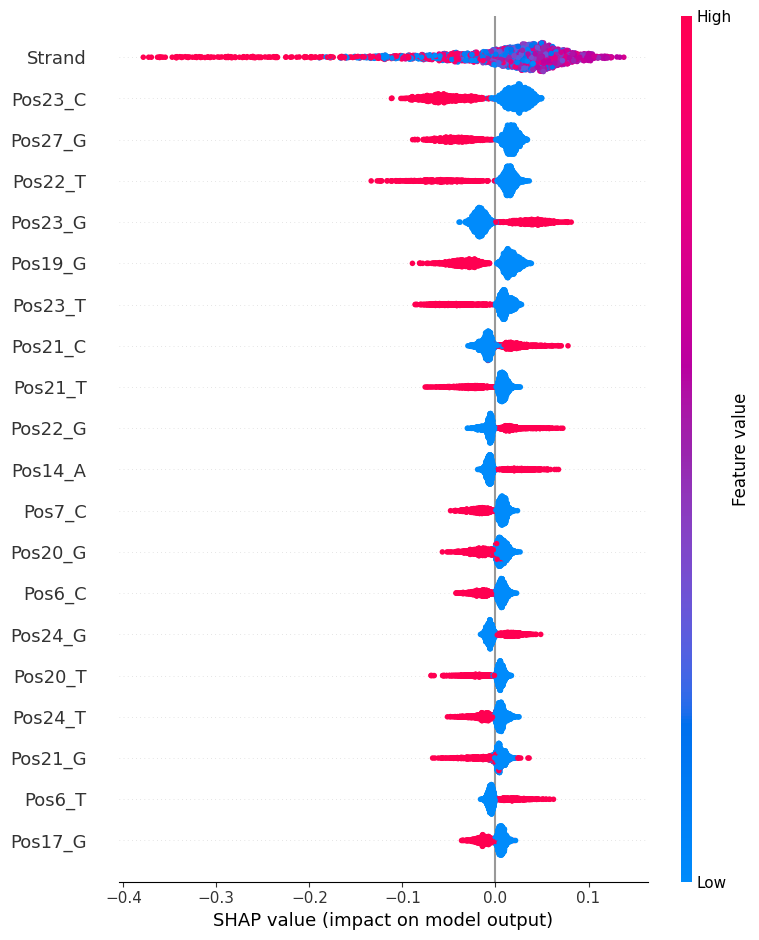

In [74]:
import shap

# 1. Recreate DNA names (0-119)
dna_labels = [f"Pos{i//4}_{['A','C','G','T'][i%4]}" for i in range(120)]

# 2. Recreate Extra names (120-137)
# We know from your previous success that 'Strand' and 'Gene Symbols' are here
extra_cols = df.drop(['Spacer', 'Activity', 'Percent Rank'], axis=1)
X_extras = pd.get_dummies(extra_cols)
extra_labels = X_extras.columns.tolist()

# 3. Combine them
full_names = dna_labels + extra_labels

# 4. THE FIX: If the list is still too short, pad it with generic names
# so the IndexError disappears forever
if len(full_names) < X.shape[1]:
    diff = X.shape[1] - len(full_names)
    extra_names = ["Gene_1", "Gene_2", "Gene_3", "Gene_4", "Gene_5", "Strand", "Gene_6"]
    full_names += [extra_names[i] for i in range(diff)]

# 5. Run the plot
shap.summary_plot(shap_values, X, feature_names=full_names)

--- Deep Dive: Guide at Index 1107 ---


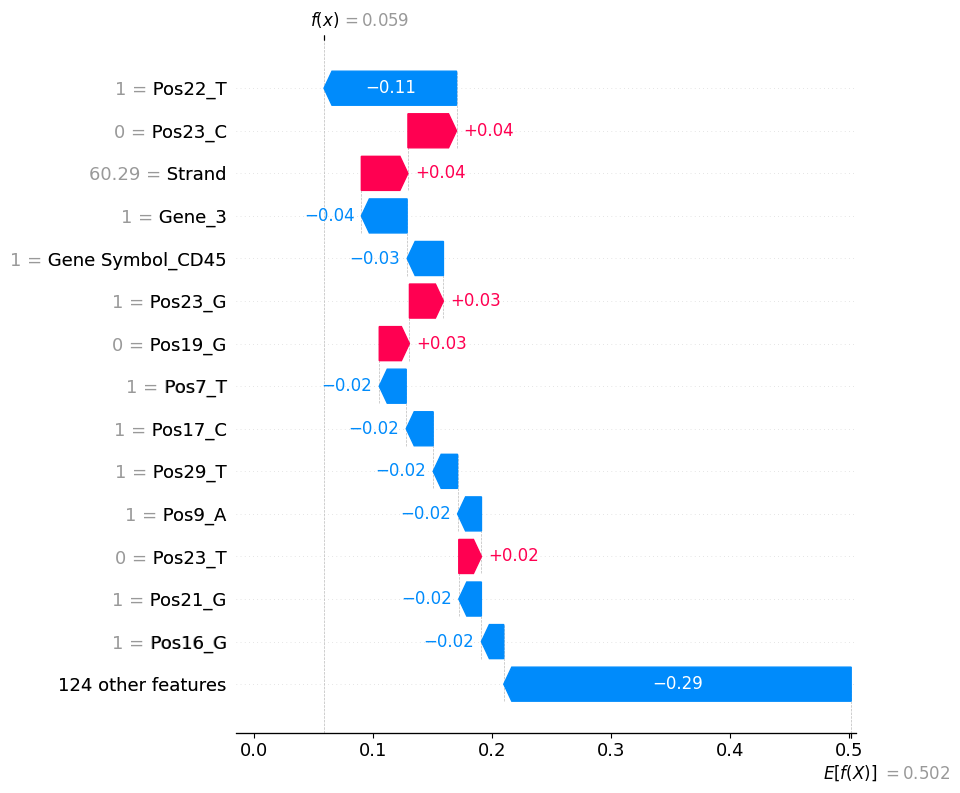

--- Deep Dive: Guide at Index 588 ---


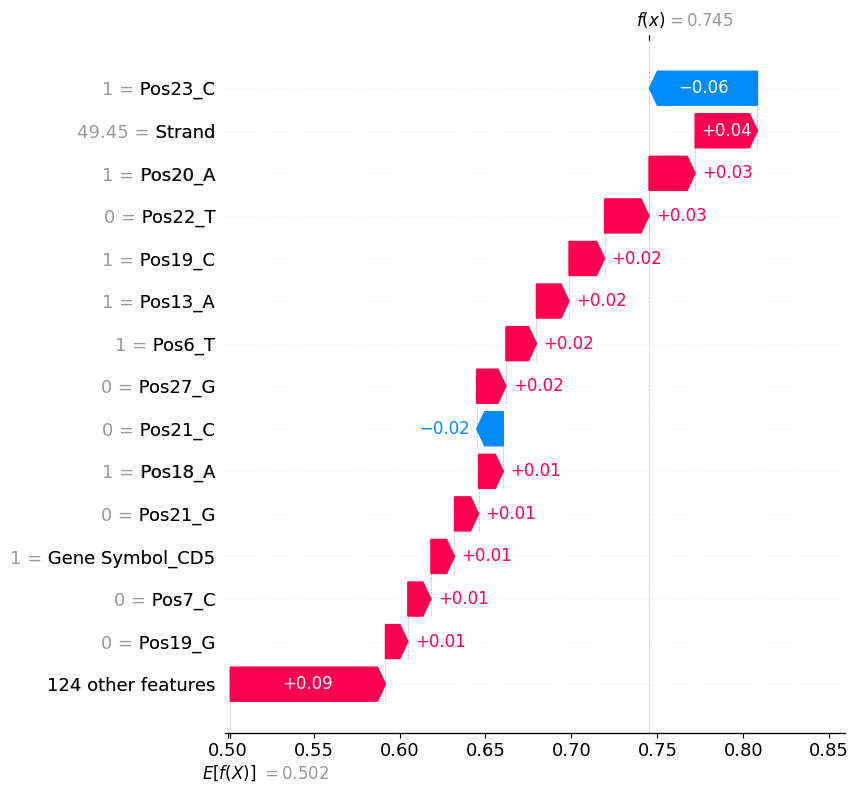

--- Deep Dive: Guide at Index 1521 ---


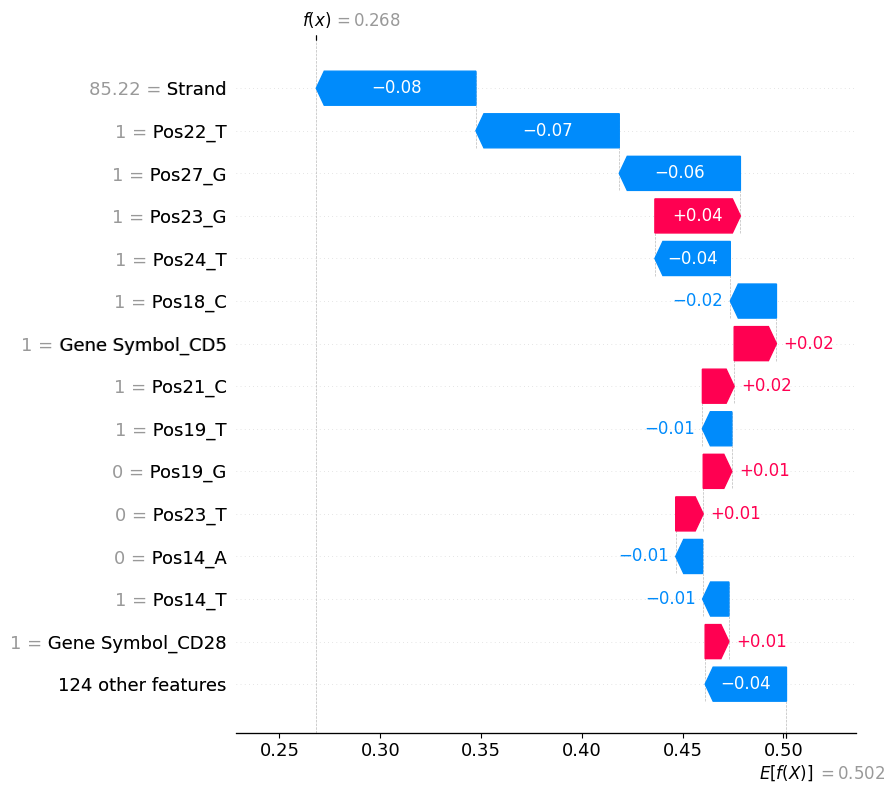

In [76]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Pick 3 truly random indices from your data
# This ensures you aren't just looking at the 'easy' examples at the start
random_indices = np.random.choice(range(X.shape[0]), size=3, replace=False)

for idx in random_indices:
    # Create the Explanation object for the specific row
    # SHAP waterfall expects an 'Explanation' object, not just raw values
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X[idx],
        feature_names=full_names
    )

    plt.figure()
    print(f"--- Deep Dive: Guide at Index {idx} ---")
    # max_display=15 shows the top 15 most influential features for this guide
    shap.plots.waterfall(exp, max_display=15)